<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Development%20of%20a%20Machine%20Learning%20Models%20for%20Real%20World%20Data%20Problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# CSA 821: Machine Learning Assignment 1
## Development of Machine Learning Models for Real-World Data Problems

#Student Name: JEFF ODHIAMBO
#Registration Number: ST62/58478/2025
#Dataset Context:Financial Inclusion in Kenya (Fintech / Socio-Economic)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the dataset (Ensure the CSV is in the same directory)
# Note: The file might be named 'Data.csv' or 'Train.csv' depending on your download
try:
    df = pd.read_csv('Financial_inclusion_dataset.csv')
except FileNotFoundError:
    print("Error: 'Financial_inclusion_dataset.csv' not found. Please ensure the file is in the correct directory.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors

# Filter for the Kenyan context to secure the bonus marks
if not df.empty:
    df_kenya = df[df['country'] == 'Kenya'].copy()
    print(f"Original dataset shape: {df.shape}")
    print(f"Kenya subset shape: {df_kenya.shape}")
    df_kenya.head()
else:
    print("DataFrame is empty, cannot filter for Kenya.")

Original dataset shape: (23524, 13)
Kenya subset shape: (6068, 13)


--- Numerical Features Summary ---


,year,household_size,age_of_respondent
count,6068.0,6068.000000,6068.000000
mean,2018.0,3.987310,39.616348
std,0.0,2.335825,17.212269
min,2018.0,1.000000,16.000000
25%,2018.0,2.000000,26.000000
50%,2018.0,4.000000,35.000000
75%,2018.0,5.000000,50.000000
max,2018.0,21.000000,95.000000


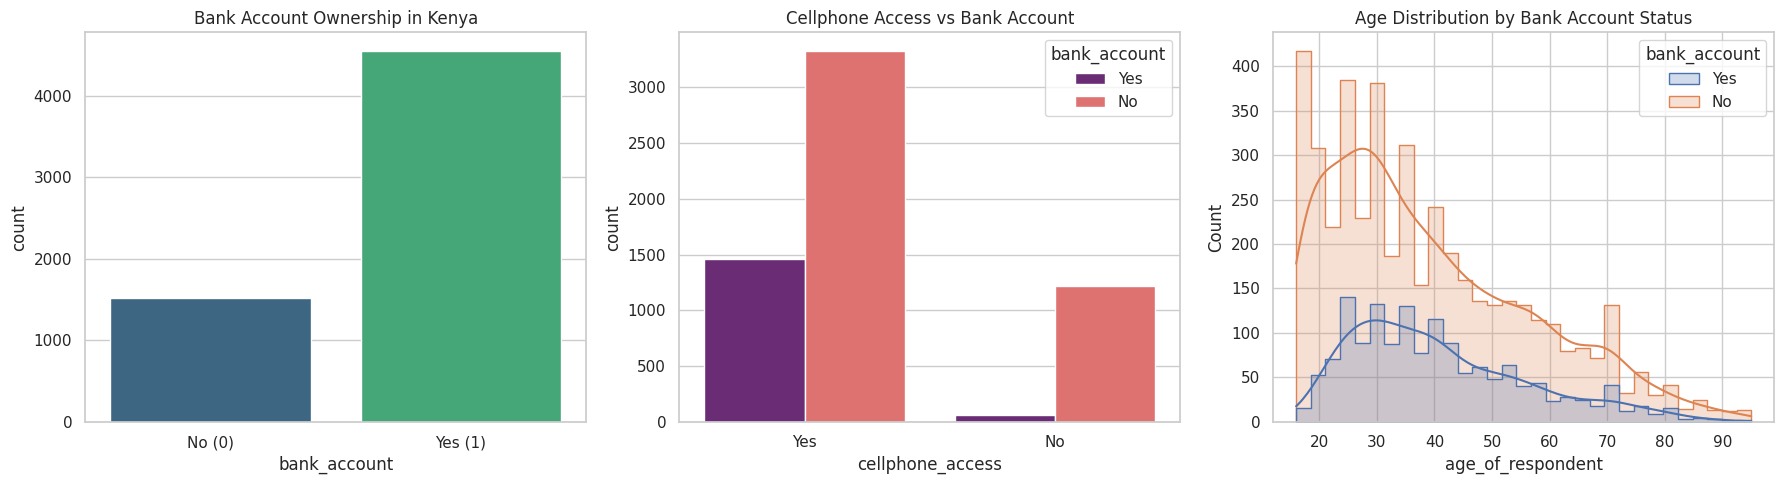

In [8]:
### 2. Exploratory Data Analysis (EDA)
# Summary Statistics for Numerical Features
print("--- Numerical Features Summary ---")
display(df_kenya[['year', 'household_size', 'age_of_respondent']].describe())

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Variable Distribution (Bank Account Ownership)
sns.countplot(x='bank_account', data=df_kenya, ax=axes[0], palette='viridis')
axes[0].set_title('Bank Account Ownership in Kenya')
axes[0].set_xticks([0, 1], ['No (0)', 'Yes (1)'])

# 2. Cellphone Access vs Bank Account
sns.countplot(x='cellphone_access', hue='bank_account', data=df_kenya, ax=axes[1], palette='magma')
axes[1].set_title('Cellphone Access vs Bank Account')

# 3. Age Distribution
sns.histplot(x='age_of_respondent', hue='bank_account', data=df_kenya, ax=axes[2], kde=True, element="step")
axes[2].set_title('Age Distribution by Bank Account Status')

plt.tight_layout()
plt.show()

In [9]:
### 3. Data Preprocessing
#We must handle missing values, outliers, encode categorical variables, and scale numerical features before feeding them into our models.
# Drop irrelevant columns (uniqueid and country, since we already filtered for Kenya)
df_kenya = df_kenya.drop(columns=['uniqueid', 'country'])

# --- Handle Outliers using IQR Method ---
num_cols = ['household_size', 'age_of_respondent']
for col in num_cols:
    Q1 = df_kenya[col].quantile(0.25)
    Q3 = df_kenya[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Clip outliers to the bounds instead of dropping rows to preserve data volume
    df_kenya[col] = np.clip(df_kenya[col], lower_bound, upper_bound)

# --- Handle Missing Values ---
# Check for missing values
print("Missing values before imputation:\n", df_kenya.isnull().sum())
# We will use SimpleImputer in our pipeline later, but let's drop rows where the target is missing
df_kenya = df_kenya.dropna(subset=['bank_account'])

# --- Define Feature Types ---
target_col = 'bank_account'
X = df_kenya.drop(columns=[target_col])
y = df_kenya[target_col]

categorical_cols = ['year', 'location_type', 'cellphone_access', 'gender_of_respondent',
                    'relationship_with_head', 'marital_status', 'education_level', 'job_type']
numerical_cols = ['household_size', 'age_of_respondent']

# --- Train-Test Split (80% Train, 20% Test) ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain set shape: {X_train.shape}, Test set shape: {X_test.shape}")


Missing values before imputation:
 year                      0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64

Train set shape: (4854, 10), Test set shape: (1214, 10)


In [11]:
### 4 & 5. Model Development and Hyperparameter Optimization
#I will implement **Logistic Regression** and **Random Forest**. To ensure robust preprocessing and prevent data leakage, I will use `Pipeline` and `ColumnTransformer`. I will apply `GridSearchCV` to tune hyperparameters.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# --- Model 1: Logistic Regression with GridSearch ---
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(max_iter=1000, random_state=42))])

param_grid_lr = {
    'classifier__C': [0.1, 1.0, 10.0],          # Regularization strength
    'classifier__penalty': ['l2'],              # Ridge regularization
    'classifier__solver': ['lbfgs', 'liblinear']
}

print("Tuning Logistic Regression...")
grid_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=3, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
print(f"Best LR Parameters: {grid_lr.best_params_}")

# --- Model 2: Random Forest with GridSearch ---
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],      # Number of trees
    'classifier__max_depth': [None, 10, 20],     # Tree depth (prevents overfitting)
    'classifier__min_samples_split': [2, 5]
}

print("\nTuning Random Forest...")
grid_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best RF Parameters: {grid_rf.best_params_}")

Tuning Logistic Regression...
Best LR Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Tuning Random Forest...
Best RF Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.801483,0.677966,0.394737,0.49896,0.822461
1,Random Forest,0.761120,0.525547,0.473684,0.49827,0.784980


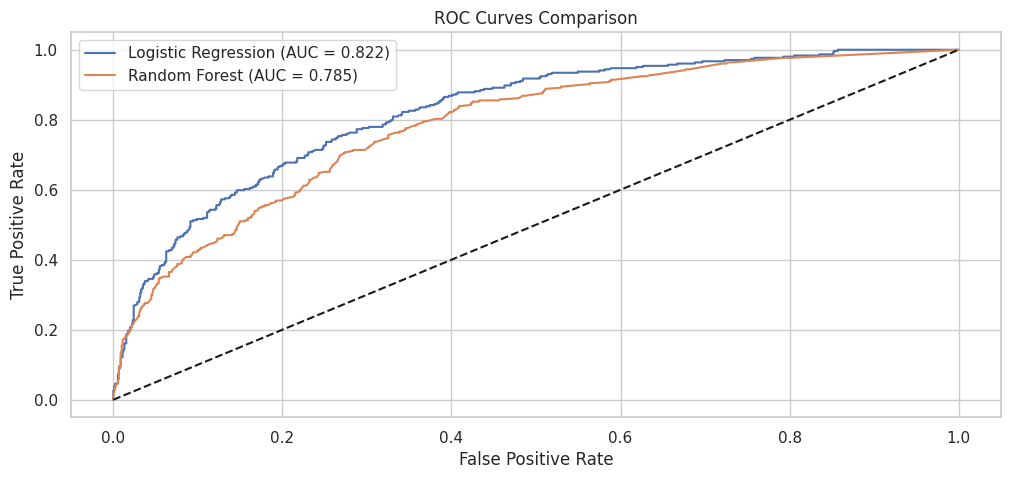

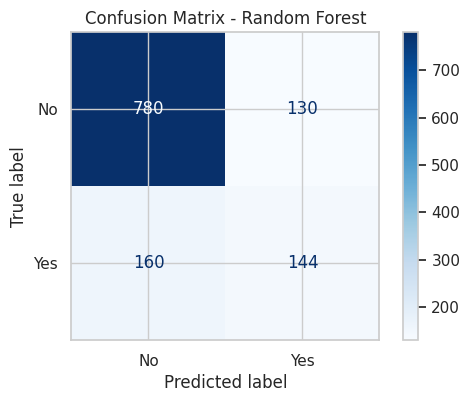

In [14]:
### 6. Performance Evaluation
#We evaluate using Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Visualizations include the Confusion Matrix and ROC Curves.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

# Predictions and Probabilities
models = {'Logistic Regression': best_lr, 'Random Forest': best_rf}
results = []

plt.figure(figsize=(12, 5))

# Convert y_test to numerical labels for consistent metric calculation
# Assuming 'Yes' is the positive class (1) and 'No' is the negative class (0)
y_test_numerical = y_test.map({'No': 0, 'Yes': 1})

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Convert y_pred to numerical labels
    y_pred_numerical = pd.Series(y_pred).map({'No': 0, 'Yes': 1})

    # Metrics - use numerical versions of y_true and y_pred
    acc = accuracy_score(y_test_numerical, y_pred_numerical)
    prec = precision_score(y_test_numerical, y_pred_numerical)
    rec = recall_score(y_test_numerical, y_pred_numerical)
    f1 = f1_score(y_test_numerical, y_pred_numerical)
    roc = roc_auc_score(y_test_numerical, y_prob) # y_prob is already probability of the positive class

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc})

    # ROC Curve - uses numerical y_test and y_prob (probabilities of positive class)
    fpr, tpr, _ = roc_curve(y_test_numerical, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc:.3f})')

# Display Metrics Table
results_df = pd.DataFrame(results)
display(results_df)

# Plot ROC Curves
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()

# Confusion Matrix for the Best Model (Random Forest usually wins on tabular data)
# ConfusionMatrixDisplay can handle string labels if both y_true and y_pred are strings,
# so we can use the original y_test for this visualization for consistency with model predictions.
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()